# Attention Compose · a hands-on tour

**Build an attention layer, change one component, and check what changes.**

This notebook uses small, seeded CPU tensors and runs in order in Python 3.12.
It demonstrates the library's behavior, not trained language generation or a
performance benchmark. Every equivalence claim is backed by an assertion.

From the repository checkout containing this notebook:

```sh
uv sync --locked --group demo
uv run --group demo jupyter lab notebooks/attention_compose_demo.ipynb
```

Choose the Python kernel from this project's environment, then **Restart Kernel
and Run All Cells**. For automated execution:

```sh
uv run --group demo python notebooks/execute.py
```

Tour: pure attention → projection choices → direct reference → kernel swap →
cached decoding → visibility/retention → INT8 → hooks → config factory.

In [1]:
import platform
from collections.abc import Mapping
from copy import deepcopy
from dataclasses import asdict
from math import sqrt

import matplotlib.pyplot as plt
import torch
from torch import Tensor, nn

from attention_compose import (
    Attention,
    AttentionConfig,
    AttentionContext,
    AttentionHook,
    AttentionSinkRetention,
    CachedAttention,
    DenseKVCacheManager,
    DenseKVState,
    FullContext,
    FullRetention,
    GroupedQueryProjection,
    LocalContext,
    LocalGlobalContext,
    MultiHeadAttention,
    MultiHeadProjection,
    MultiQueryProjection,
    QuantizedCachedAttention,
    ReferenceAttentionKernel,
    SDPAAttentionKernel,
    SlidingWindowRetention,
    build_attention,
)

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False})
print(f"Python {platform.python_version()} · PyTorch {torch.__version__} · CPU")
BATCH, TOKENS, WIDTH, HEADS = 2, 24, 64, 4
x = torch.randn(BATCH, TOKENS, WIDTH)

Python 3.12.11 · PyTorch 2.14.0 · CPU


## 1 · Start with pure attention

`MultiHeadAttention` is a convenience composition. It accepts `[batch, tokens,
d_model]` and returns `AttentionOutput(output, state)`. The default state is
`None`; there is no cache unless you choose a stateful manager. Causality is on
by default. This layer includes Q/K/V and output projections, but no residual,
normalization, or positional encoding.

In [2]:
plain = MultiHeadAttention(WIDTH, HEADS).eval()
with torch.inference_mode():
    plain_result = plain(x)
assert plain_result.output.shape == x.shape
assert plain_result.state is None
print("Input shape: ", tuple(x.shape))
print("Output shape:", tuple(plain_result.output.shape))
print("State:       ", plain_result.state)

Input shape:  (2, 24, 64)
Output shape: (2, 24, 64)
State:        None


## 2 · Change only the projection: MHA → GQA → MQA

The query-head count stays fixed. MHA has one KV head per query head; GQA shares
KV heads among groups; MQA shares one KV head across all queries. The same
orchestrator and kernel handle all three. These separately initialized models
are different parameterizations, so their output values need not match.

In [3]:
projections = {
    "MHA": MultiHeadProjection(WIDTH, HEADS),
    "GQA": GroupedQueryProjection(WIDTH, HEADS, 2),
    "MQA": MultiQueryProjection(WIDTH, HEADS),
}
for name, projection in projections.items():
    model = Attention(projection).eval()
    with torch.inference_mode():
        qkv = projection.project(x)
        result = model(x)
    assert result.output.shape == x.shape
    print(f"{name}: Q {tuple(qkv.q.shape)} | K/V {tuple(qkv.k.shape)}")

MHA: Q (2, 4, 24, 16) | K/V (2, 4, 24, 16)
GQA: Q (2, 4, 24, 16) | K/V (2, 2, 24, 16)
MQA: Q (2, 4, 24, 16) | K/V (2, 1, 24, 16)


## 3 · Compare composition with a direct implementation

The function below contains the equations directly: linear projection, head
grouping, a causal mask, softmax, and output projection. It uses no library
components, inheritance, or SDPA. Sharing the same **weights and input** makes
the comparison meaningful. The full test suite also checks gradients.

In [4]:
def direct_causal_attention(
    inputs: Tensor, weights: Mapping[str, Tensor], query_heads: int, kv_heads: int
) -> Tensor:
    batch, tokens, width = inputs.shape
    dim = width // query_heads
    q = (inputs @ weights["q_proj.weight"].T).reshape(batch, tokens, query_heads, dim)
    k = (inputs @ weights["k_proj.weight"].T).reshape(batch, tokens, kv_heads, dim)
    v = (inputs @ weights["v_proj.weight"].T).reshape(batch, tokens, kv_heads, dim)
    q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
    head_index = [h // (query_heads // kv_heads) for h in range(query_heads)]
    scores = (q @ k[:, head_index].transpose(-1, -2)) / sqrt(dim)
    future = torch.ones(tokens, tokens, dtype=torch.bool).triu(1)
    probabilities = scores.masked_fill(future, float("-inf")).softmax(-1)
    attended = (probabilities @ v[:, head_index]).transpose(1, 2).reshape(batch, tokens, width)
    return attended @ weights["out_proj.weight"].T


with torch.inference_mode():
    for name, projection in projections.items():
        composite = Attention(projection).eval()(x).output
        direct = direct_causal_attention(
            x, dict(projection.named_parameters()), HEADS, projection.num_kv_heads
        )
        torch.testing.assert_close(composite, direct, atol=1e-6, rtol=1e-5)
        print(f"{name}: maximum absolute difference = {(composite - direct).abs().max():.2e}")

MHA: maximum absolute difference = 1.19e-07
GQA: maximum absolute difference = 8.94e-08
MQA: maximum absolute difference = 8.94e-08


## 4 · Swap the kernel without changing the model weights

The reference kernel spells out attention; SDPA delegates execution to PyTorch.
An explicit absolute-position mask is used in both, including during decoding.
This checks numerical equivalence, not relative speed.

In [5]:
reference = Attention(deepcopy(projections["GQA"]), kernel=ReferenceAttentionKernel()).eval()
sdpa = deepcopy(reference)
sdpa.kernel = SDPAAttentionKernel()
with torch.inference_mode():
    ref_output = reference(x).output
    fast_output = sdpa(x).output
torch.testing.assert_close(ref_output, fast_output, atol=1e-6, rtol=1e-5)
print(f"Kernel-swap maximum difference: {(ref_output - fast_output).abs().max():.2e}")

Kernel-swap maximum difference: 8.94e-08


## 5 · Add a cache: full-sequence, token, and chunked decoding agree

State belongs to the caller. Pass the returned state into the next call; pass
`None` to start a new sequence. The orchestrator never reads cache fields.
Here, several chunk sizes—including a whole prompt—must produce the same result.

In [6]:
cached = Attention(deepcopy(projections["GQA"]), DenseKVCacheManager()).eval()
errors: list[float] = []
chunk_sizes = [1, 3, 8, TOKENS]
with torch.inference_mode():
    full_output = cached(x).output
    for chunk_size in chunk_sizes:
        state: DenseKVState | None = None
        pieces: list[Tensor] = []
        for chunk in x.split(chunk_size, dim=1):
            result = cached(chunk, state)
            state = result.state
            pieces.append(result.output)
        decoded = torch.cat(pieces, dim=1)
        torch.testing.assert_close(decoded, full_output, atol=1e-6, rtol=1e-5)
        assert state is not None and state.next_position == TOKENS
        errors.append(float((decoded - full_output).abs().max()))
        print(
            f"Chunk size {chunk_size:2}: max error {errors[-1]:.2e}; "
            f"next position {state.next_position}"
        )
print("Cache K shape:", tuple(state.k.shape))

Chunk size  1: max error 2.98e-07; next position 24
Chunk size  3: max error 2.98e-07; next position 24
Chunk size  8: max error 6.71e-08; next position 24
Chunk size 24: max error 0.00e+00; next position 24
Cache K shape: (2, 2, 24, 16)


## 6 · See what each query is allowed to attend to

Rows are queries; columns are keys. Dark cells are visible **after causality is
applied**. Context policies change visibility; retention policies decide what
survives for the next call. These sparse patterns still use dense Boolean masks,
not computationally sparse kernels.

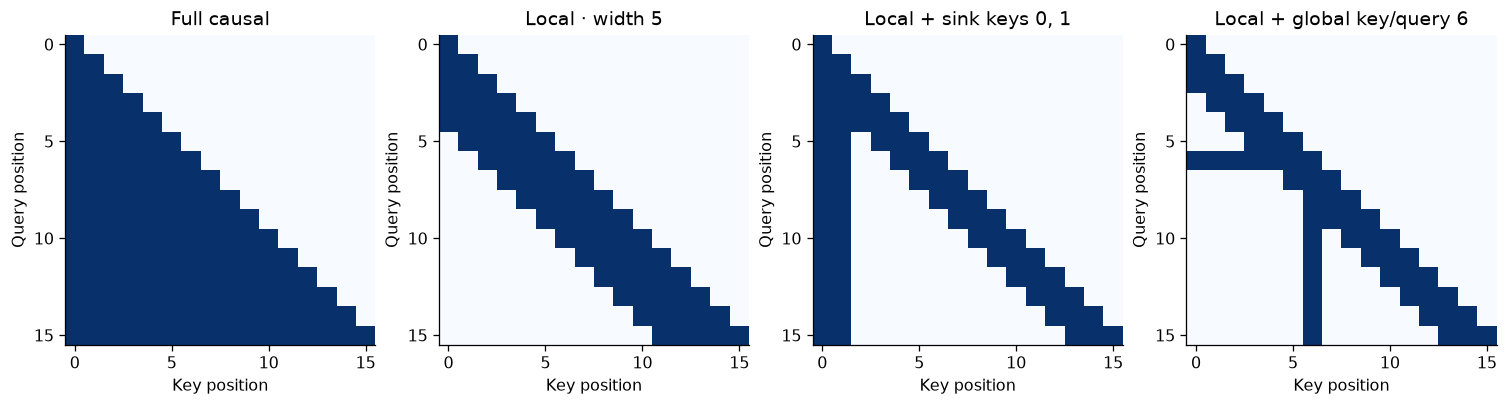

In [7]:
length = 16
positions = torch.arange(length)
dummy = torch.zeros(1, 1, length, WIDTH // HEADS)
base_context = AttentionContext(dummy, dummy, positions)
policies = {
    "Full causal": FullContext(),
    "Local · width 5": LocalContext(5),
    "Local + sink keys 0, 1": LocalGlobalContext(3, num_global_tokens=2),
    "Local + global key/query 6": LocalGlobalContext(3, global_positions=(6,), global_queries=True),
}
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), constrained_layout=True)
for ax, (title, policy) in zip(axes, policies.items(), strict=True):
    selected = policy.apply(base_context, positions)
    visible = positions[None, :] <= positions[:, None]
    if selected.allowed is not None:
        visible = visible & selected.allowed
    ax.imshow(visible.numpy(), cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set(title=title, xlabel="Key position", ylabel="Query position")
    ax.set_xticks([0, 5, 10, 15])
    ax.set_yticks([0, 5, 10, 15])
plt.show()

## 7 · Bound stored state with windows and attention sinks

Use a total cache budget of eight entries. The sink variant preserves two initial
tokens plus six recent positions. Pair retention with the corresponding context
mask for chunk-invariant causal behavior. Eviction affects **next-call state**:
even a chunk larger than the budget retains its needed current context.

The chart counts stored tokens, not peak memory. Current prefill tensors can be
larger than the retained cache. Sink compositions start at position zero.

Full           retained positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Sliding        retained positions: [16, 17, 18, 19, 20, 21, 22, 23]
Sinks + recent retained positions: [0, 1, 18, 19, 20, 21, 22, 23]


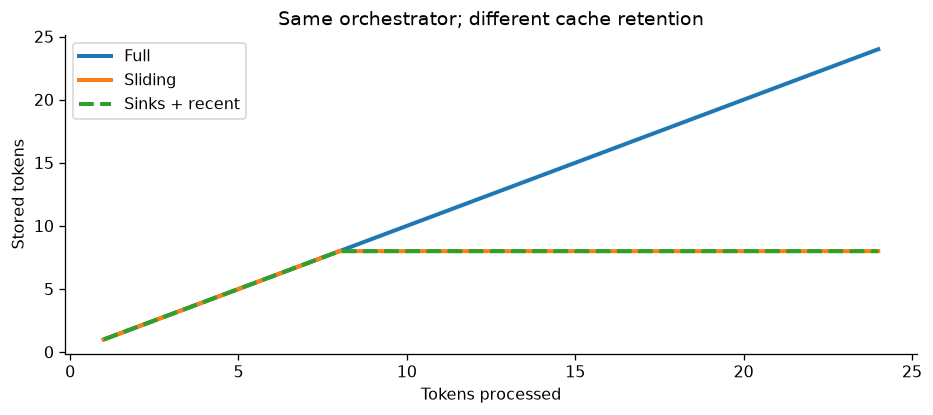

In [8]:
BUDGET, SINKS = 8, 2
cache_models = {
    "Full": Attention(deepcopy(projections["GQA"]), DenseKVCacheManager(FullRetention())),
    "Sliding": Attention(
        deepcopy(projections["GQA"]),
        DenseKVCacheManager(SlidingWindowRetention(BUDGET)),
        LocalContext(BUDGET),
    ),
    "Sinks + recent": Attention(
        deepcopy(projections["GQA"]),
        DenseKVCacheManager(AttentionSinkRetention(BUDGET, SINKS), require_zero_start=True),
        LocalGlobalContext(BUDGET - SINKS, num_global_tokens=SINKS),
    ),
}
fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
with torch.inference_mode():
    for name, model in cache_models.items():
        model.eval()
        state = None
        lengths: list[int] = []
        pieces = []
        expected = model(x).output
        for token in x.split(1, dim=1):
            result = model(token, state)
            state = result.state
            assert state is not None
            pieces.append(result.output)
            lengths.append(state.positions.numel())
        torch.testing.assert_close(torch.cat(pieces, 1), expected, atol=1e-6, rtol=1e-5)
        # Exercise a multi-token chunk larger than the retained budget as well.
        chunk_state: DenseKVState | None = None
        chunks: list[Tensor] = []
        for chunk in x.split(11, dim=1):
            chunk_result = model(chunk, chunk_state)
            chunk_state = chunk_result.state
            chunks.append(chunk_result.output)
        torch.testing.assert_close(torch.cat(chunks, 1), expected, atol=1e-6, rtol=1e-5)
        if name != "Full":
            assert max(lengths) <= BUDGET
        print(f"{name:14} retained positions: {state.positions.tolist()}")
        ax.plot(
            range(1, TOKENS + 1),
            lengths,
            label=name,
            linewidth=2.5,
            linestyle="--" if name == "Sinks + recent" else "-",
        )
ax.set(
    xlabel="Tokens processed",
    ylabel="Stored tokens",
    title="Same orchestrator; different cache retention",
)
ax.legend()
plt.show()

## 8 · Trade exact cache values for INT8 storage

Use identical projection weights and GQA layout. INT8 stores quantized values
plus FP32 per-token/head scales, then dequantizes for the attention kernel. It is
inference-only and approximate. Storage below counts tensor payload bytes for K,
V, positions, and scales; it excludes Python overhead and temporary tensors.
This is **not** a peak-memory or speed benchmark.

Max output error: 0.005059 · RMS output error: 0.000604
Cache tensor bytes: dense 12,480; INT8 4,032; ratio 3.10×


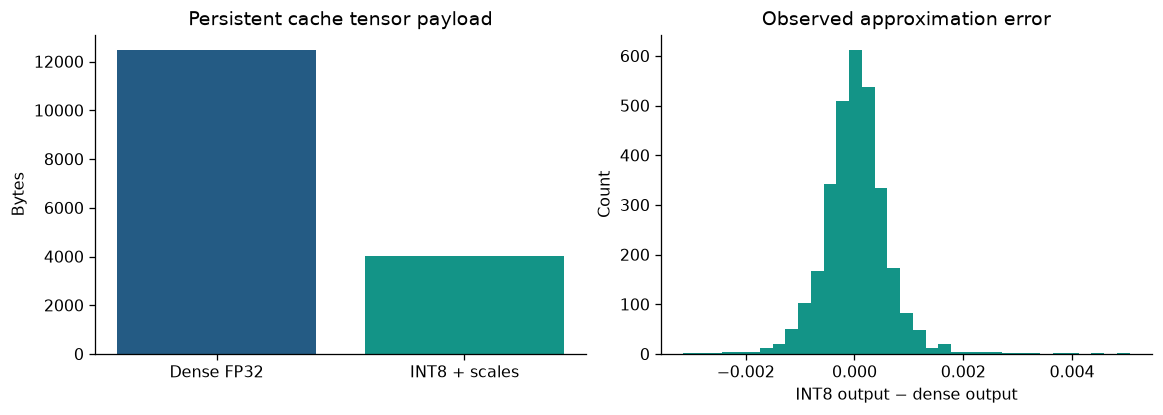

In [9]:
dense = CachedAttention(WIDTH, HEADS, num_kv_heads=2).eval()
int8 = QuantizedCachedAttention(WIDTH, HEADS, num_kv_heads=2).eval()
int8.projection.load_state_dict(dense.projection.state_dict())
with torch.inference_mode():
    dense_result = dense(x)
    int8_result = int8(x)
assert dense_result.state is not None and int8_result.state is not None
delta = int8_result.output - dense_result.output
max_error = float(delta.abs().max())
rms_error = float(delta.square().mean().sqrt())
assert max_error < 0.01 and rms_error < 0.003


def tensor_bytes(*tensors: Tensor) -> int:
    return sum(t.numel() * t.element_size() for t in tensors)


ds, qs = dense_result.state, int8_result.state
dense_bytes = tensor_bytes(ds.k, ds.v, ds.positions)
int8_bytes = tensor_bytes(qs.k.values, qs.k.scales, qs.v.values, qs.v.scales, qs.positions)
assert int8_bytes < dense_bytes
print(f"Max output error: {max_error:.6f} · RMS output error: {rms_error:.6f}")
print(
    f"Cache tensor bytes: dense {dense_bytes:,}; INT8 {int8_bytes:,}; "
    f"ratio {dense_bytes / int8_bytes:.2f}×"
)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(
    ["Dense FP32", "INT8 + scales"], [dense_bytes, int8_bytes], color=["#245b84", "#139487"]
)
axes[0].set(ylabel="Bytes", title="Persistent cache tensor payload")
axes[1].hist(delta.flatten().numpy(), bins=35, color="#139487")
axes[1].set(
    xlabel="INT8 output − dense output", ylabel="Count", title="Observed approximation error"
)
plt.show()

## 9 · Add behavior with a registered hook

Override only the stage you need. This output hook has a trainable gain, appears
in `state_dict`, and receives a gradient. Normal training is enabled in this
cell; `.eval()` and `torch.inference_mode()` solve different problems.

Other hook stages are `after_projection`, `before_attention`, and
`after_attention`. A positional Q/K transform belongs in `after_projection`,
before keys enter the cache.

In [10]:
class OutputGain(AttentionHook):
    def __init__(self) -> None:
        super().__init__()
        self.gain = nn.Parameter(torch.tensor(1.0))

    def after_output(self, output: Tensor) -> Tensor:
        return output * self.gain


gain_hook = OutputGain()
hooked = MultiHeadAttention(WIDTH, HEADS, hooks=[gain_hook])
loss = hooked(x).output.square().mean()
loss.backward()
assert gain_hook.gain.grad is not None
assert "hooks.0.gain" in hooked.state_dict()
print("Registered parameter:", "hooks.0.gain")
print(f"Loss: {loss.item():.6f} · gain gradient: {gain_hook.gain.grad.item():.6f}")

Registered parameter: hooks.0.gain
Loss: 0.020578 · gain gradient: 0.041156


## 10 · Build the same kind of composition from config

The builder validates dimensions and policy combinations. With sink retention
plus local/global context, `window_size` is the **total** budget; the sink count
is subtracted from the local width. Dynamic factory state covers supported
state types; direct composition gives the most precise static specialization.

In [11]:
config = AttentionConfig(
    d_model=WIDTH,
    num_query_heads=HEADS,
    num_kv_heads=2,
    cache="dense",
    retention="sinks",
    context="local_global",
    window_size=BUDGET,
    num_sink_tokens=SINKS,
    kernel="sdpa",
)
built = build_attention(config).eval()
with torch.inference_mode():
    first = built(x[:, :12])
    second = built(x[:, 12:], first.state)
assert isinstance(second.state, DenseKVState)
assert second.state.positions.numel() == BUDGET
assert second.state.next_position == TOKENS
print(asdict(config))
print("Final retained positions:", second.state.positions.tolist())
print("All demo assertions passed.")

{'d_model': 64, 'num_query_heads': 4, 'num_kv_heads': 2, 'cache': 'dense', 'retention': 'sinks', 'context': 'local_global', 'kernel': 'sdpa', 'window_size': 8, 'num_sink_tokens': 2, 'num_global_tokens': 0, 'global_positions': (), 'global_queries': False, 'causal': True, 'dropout': 0.0, 'bias': False, 'detach_cache': False}
Final retained positions: [0, 1, 18, 19, 20, 21, 22, 23]
All demo assertions passed.


## Try changing one axis

- Change the GQA KV-head count from `2` to `1`; inspect the smaller K/V shape.
- Change `BUDGET` and `SINKS`, keeping `0 <= SINKS < BUDGET`; rerun from that cell.
- Set `global_queries=True` in a local/global policy and inspect its visibility map.
- Swap `SDPAAttentionKernel` for `ReferenceAttentionKernel` in your own composition.

Use the [README](../README.md) for API details and the `tests/test_direct_*.py`
suite for standalone output/gradient comparisons. Reset state to `None` when
starting another sequence or changing the module's batch shape, dtype, or device.
There is no trained model or generation loop hidden in this demo.